# SH3 inconsistency study — overview

Reads the per-`(config, scene, manipulation)` `results.json` from
`scripts/sh3_inconsistency_study.py` (under `results/inconsistency_study/`) and

1. plots how decomposition degrades as the training data is made **inconsistent** (per-image
   constant shifts of the GT albedo/roughness/metallic, re-rendered as new targets);
2. for a chosen `(scene, manipulation)`: renders the **manipulated intrinsic maps** and the
   **relight visuals** (est vs GT panels + videos), mirroring the canonical notebook.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "idr").is_dir())
os.chdir(REPO)
for p in (str(REPO), str(REPO / "scripts")):
    if p not in sys.path: sys.path.insert(0, p)
os.environ.setdefault("WANDB_MODE", "disabled")
from idr.paths import RESULTS_DIR
RESULTS_ROOT = RESULTS_DIR / "inconsistency_study"
DEVICE = "cuda"
print("results root:", RESULTS_ROOT)

results root: /home/felix/Projects/image-intrinsics/results/inconsistency_study


## 1. Load results

In [3]:
def load_study(root=RESULTS_ROOT):
    rows = []
    for p in sorted(Path(root).glob("*/*/*/results.json")):
        r = json.loads(p.read_text())
        row = dict(config=r["config"], scene=r["scene"], manip=r["manip_name"],
                   out_dir=r["out_dir"], scene_dir=r["scene_dir"])
        for par in r.get("params", ["albedo","roughness","metallic"]):
            row[f"m_{par}"] = float(r["manip"].get(f"m_{par}", 0.0))   # strength per param
        row.update({k: r["metrics"].get(k) for k in
                    ("recon_rmse","albedo_rmse","roughness_rmse","metallic_rmse","relighting_rmse",
                     "manip_rmse_albedo","manip_rmse_roughness","manip_rmse_metallic")})
        rows.append(row)
    df = pd.DataFrame(rows)
    if df.empty:
        raise SystemExit(f"no results under {root} — run scripts/sh3_inconsistency_study.py first")
    return df

df = load_study()
print(f"{len(df)} run(s) | configs={sorted(df.config.unique())} | manips={sorted(df.manip.unique())}")
CONFIG = sorted(df.config.unique())[0]
df = df[df.config == CONFIG]; print("showing config:", CONFIG)
df.groupby("manip").size()

536 run(s) | configs=['light_mono'] | manips=['albedo0.2', 'albedo0.2_metallic0.2_roughness0.2', 'albedo0.4', 'albedo0.4_metallic0.4_roughness0.4', 'albedo0.6', 'metallic0.4', 'roughness0.4', 'unmanip']
showing config: light_mono


manip
albedo0.2                             67
albedo0.2_metallic0.2_roughness0.2    67
albedo0.4                             67
albedo0.4_metallic0.4_roughness0.4    67
albedo0.6                             67
metallic0.4                           67
roughness0.4                          67
unmanip                               67
dtype: int64

## 2. Degradation vs manipulation

Bars: mean metric per manipulation (over scenes). The unmanipulated control (`unmanip`) is the
config's floor; every manipulation should raise `recon_rmse` (the model can't fit inconsistent
images) and the intrinsic/relight errors.

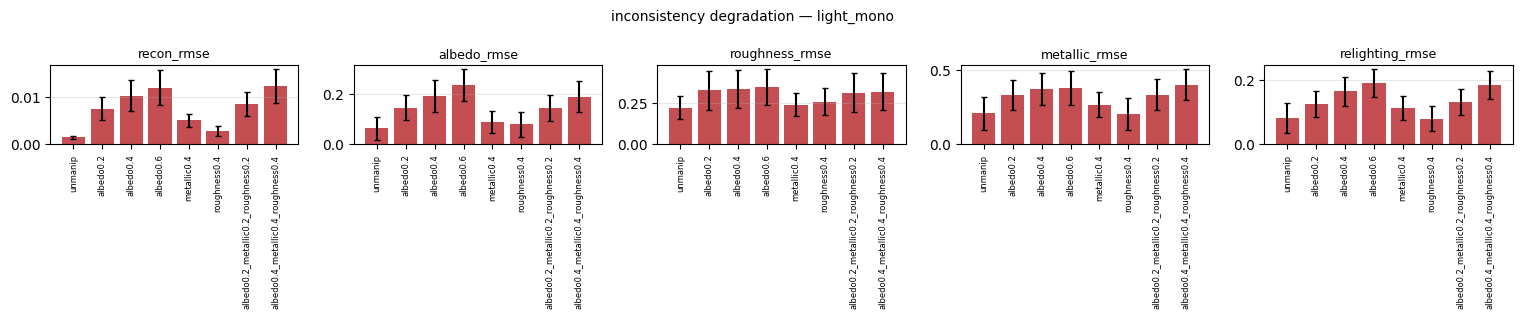

In [4]:
METRICS = ["recon_rmse","albedo_rmse","roughness_rmse","metallic_rmse","relighting_rmse"]
def manip_order(present):
    # unmanip first, then by number of params, then name
    return sorted(present, key=lambda s: (s!="unmanip", s.count("_"), s))

def overview(df):
    manips = manip_order(set(df.manip)); x = np.arange(len(manips))
    fig, ax = plt.subplots(1, len(METRICS), figsize=(3.1*len(METRICS), 3.2), squeeze=False)
    for ci, met in enumerate(METRICS):
        a = ax[0][ci]
        means = [df[df.manip==m][met].mean() for m in manips]
        stds  = [df[df.manip==m][met].std()  for m in manips]
        a.bar(x, means, yerr=stds, capsize=2, color="#C44E52")
        a.set_xticks(x); a.set_xticklabels(manips, rotation=90, fontsize=6)
        a.set_title(met, fontsize=9); a.grid(axis="y", alpha=0.3)
    fig.suptitle(f"inconsistency degradation — {CONFIG}", fontsize=10)
    plt.tight_layout(); plt.show()

overview(df)

### Trend vs manipulation strength (single-parameter manipulations)

For each parameter, the metrics vs its shift strength (holding the others at 0).

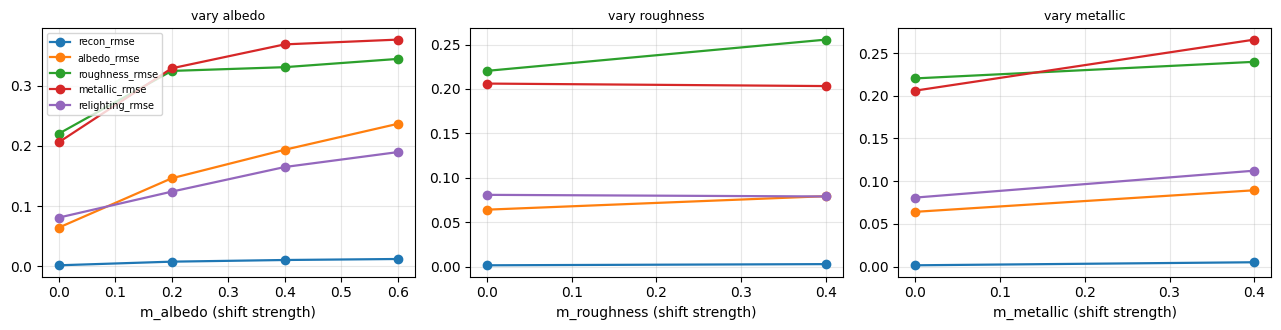

In [5]:
def trends(df):
    fig, ax = plt.subplots(1, 3, figsize=(13, 3.4), squeeze=False)
    for ci, par in enumerate(["albedo","roughness","metallic"]):
        others = [f"m_{o}" for o in ["albedo","roughness","metallic"] if o != par]
        sub = df[(df[others[0]]==0) & (df[others[1]]==0)]                 # only this param varies
        g = sub.groupby(f"m_{par}")[["recon_rmse","albedo_rmse","roughness_rmse",
                                     "metallic_rmse","relighting_rmse"]].mean().sort_index()
        a = ax[0][ci]
        for met in ["recon_rmse","albedo_rmse","roughness_rmse","metallic_rmse","relighting_rmse"]:
            a.plot(g.index, g[met], marker="o", label=met, lw=1.6)
        a.set_xlabel(f"m_{par} (shift strength)"); a.set_title(f"vary {par}", fontsize=9)
        a.grid(alpha=0.3)
        if ci==0: a.legend(fontsize=7)
    plt.tight_layout(); plt.show()

trends(df)

In [6]:
df.groupby("manip")[METRICS].mean().round(4)

,recon_rmse,albedo_rmse,roughness_rmse,metallic_rmse,relighting_rmse
manip,,,,,
albedo0.2,0.0075,0.1462,0.3248,0.3292,0.1240
albedo0.2_metallic0.2_roughness0.2,0.0084,0.1458,0.3117,0.3324,0.1312
albedo0.4,0.0103,0.1937,0.3311,0.3690,0.1649
albedo0.4_metallic0.4_roughness0.4,0.0123,0.1899,0.3182,0.3979,0.1832
albedo0.6,0.0120,0.2368,0.3448,0.3769,0.1897
metallic0.4,0.0050,0.0893,0.2398,0.2658,0.1123
roughness0.4,0.0028,0.0793,0.2555,0.2032,0.0789
unmanip,0.0015,0.0641,0.2204,0.2060,0.0808


## 3. Per-scene visuals (on demand)

Pick a `(scene, manipulation)`. This renders the manipulated intrinsic maps and the relight
visuals (est vs GT). Rendering runs here, not in the batch.

In [11]:
SCENE = df.scene.iloc[0]
MANIP = "albedo0.6" if "albedo0.6" in set(df.manip) else sorted(df.manip)[-1]

def resolve(scene, manip, df=df):
    hit = df[(df.scene==scene)&(df.manip==manip)]
    if hit.empty: raise SystemExit(f"no run for {scene}/{manip}")
    r = hit.iloc[0]; return Path(r.out_dir), Path(r.scene_dir)

RUN_DIR, SCENE_DIR = resolve(SCENE, MANIP); DS = 1
shifts = np.array(json.loads((RUN_DIR/"shifts.json").read_text())["shifts"], np.float32)
print(RUN_DIR, "| shifts", shifts.shape)

/home/felix/Projects/image-intrinsics/results/inconsistency_study/light_mono/1c349305_v0/albedo0.6 | shifts (16, 3)


### Manipulated intrinsic maps

GT vs the per-training-image manipulated maps that generated the (inconsistent) targets.

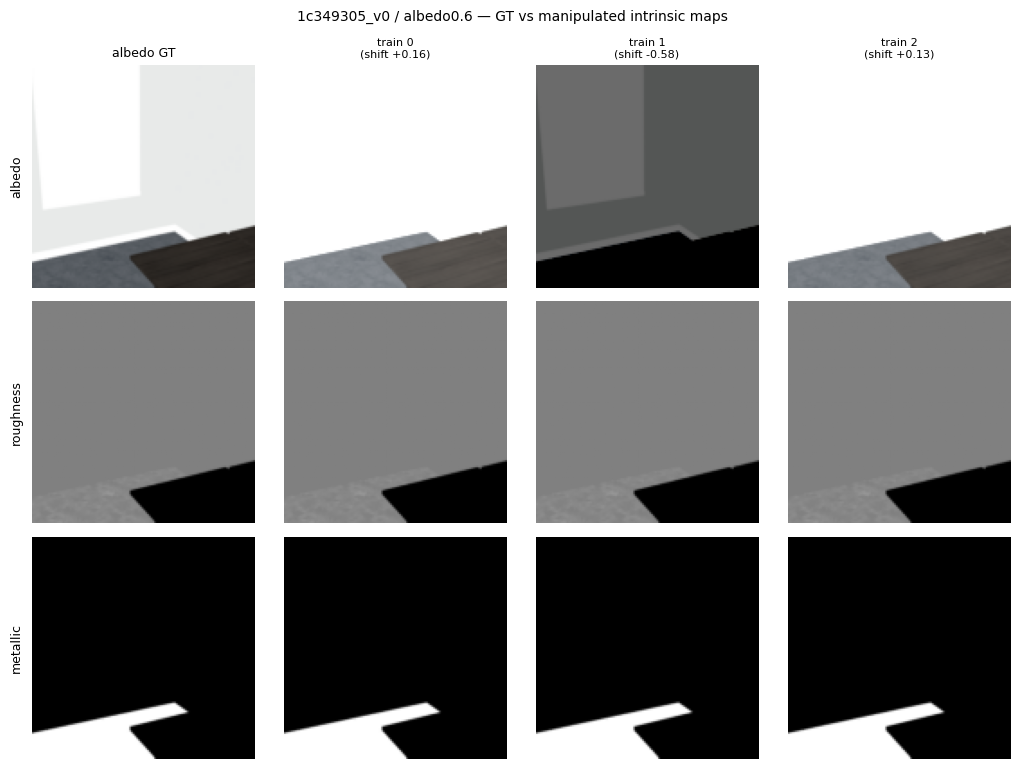

In [12]:
from canonical_relight_render import load_gt_intrinsics
gt = load_gt_intrinsics(SCENE_DIR, DS)
n = min(3, shifts.shape[0])
params = [("albedo", gt["albedo"], 0, None),
          ("roughness", gt["roughness"][...,0], 1, "gray"),
          ("metallic", gt["metallic"][...,0], 2, "gray")]
fig, ax = plt.subplots(len(params), n+1, figsize=(2.6*(n+1), 2.6*len(params)), squeeze=False)
for ri,(name, gmap, pi, cm) in enumerate(params):
    ax[ri][0].imshow(np.clip(gmap,0,1), cmap=cm, vmin=0 if cm else None, vmax=1 if cm else None)
    ax[ri][0].set_title(f"{name} GT" if ri==0 else "", fontsize=9); ax[ri][0].axis("off")
    ax[ri][0].text(-0.1,0.5,name,transform=ax[ri][0].transAxes,rotation=90,va="center",fontsize=9)
    for j in range(n):
        mmap = np.clip(gmap + shifts[j, pi], 0, 1)
        ax[ri][j+1].imshow(mmap, cmap=cm, vmin=0 if cm else None, vmax=1 if cm else None); ax[ri][j+1].axis("off")
        if ri==0: ax[ri][j+1].set_title(f"train {j}\n(shift {shifts[j,pi]:+.2f})", fontsize=8)
fig.suptitle(f"{SCENE} / {MANIP} — GT vs manipulated intrinsic maps", fontsize=10)
plt.tight_layout(); plt.show()

### Relight comparison panels + videos (est vs GT)

Same on-demand relight as the canonical notebook: GT-relit vs EST-relit under SH3 and a sharp
env highlight, then the two orbit videos (azimuth −45→45 at elevation 45).

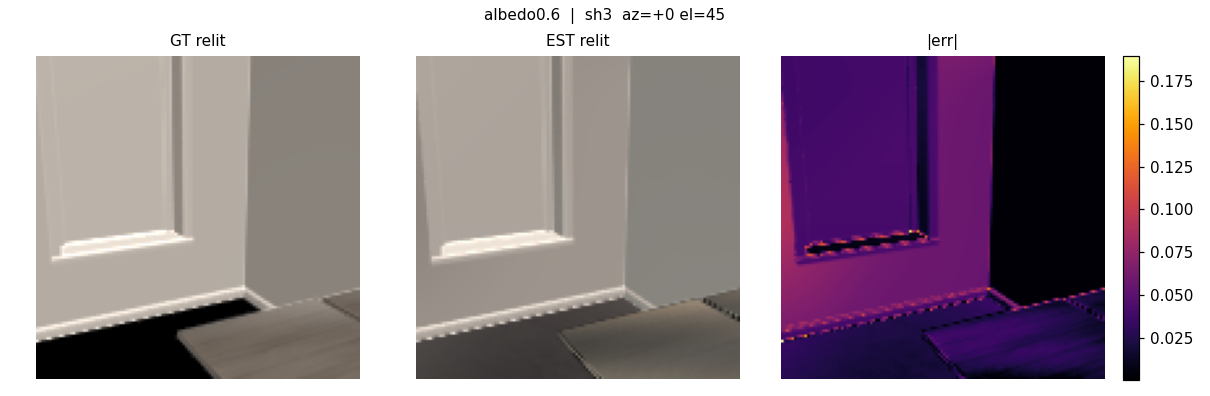

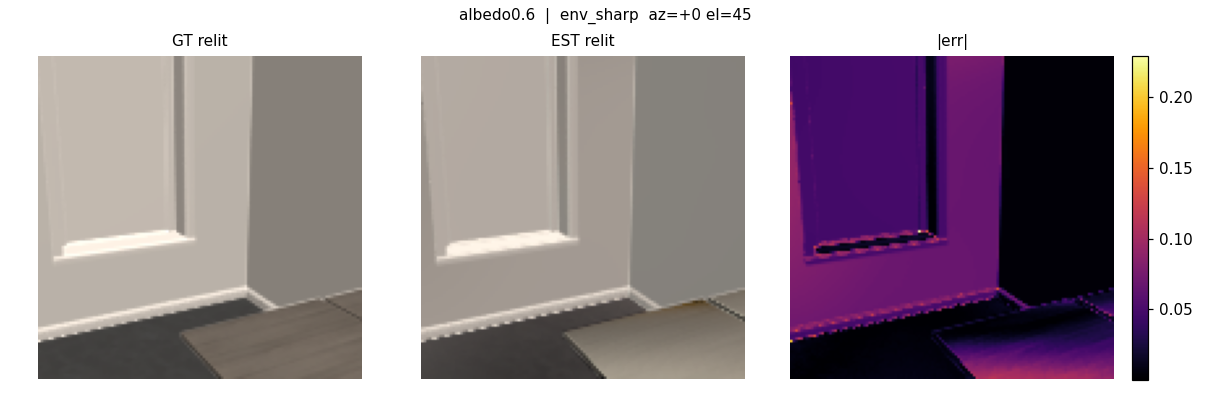

In [13]:
from canonical_relight_render import render_comparison, render_relight_video
from IPython.display import Image as IPyImage, Video, display
for mode in ("sh3", "env_sharp"):
    display(IPyImage(filename=render_comparison(RUN_DIR, SCENE_DIR, mode=mode, az=0., el=45., ds=DS, device=DEVICE)))

In [10]:
for mode in ("env_sharp", "sh3"):
    p = render_relight_video(RUN_DIR, SCENE_DIR, mode=mode, az_from=-45, az_to=45, elev=45,
                             n_frames=61, ds=DS, device=DEVICE, fps=20)
    print(p)
    display(Video(p, embed=True, width=760) if p.endswith(".mp4") else IPyImage(filename=p))

/home/felix/Projects/image-intrinsics/results/inconsistency_study/light_mono/1c349305_v0/unmanip/relight_env_sharp.mp4


/home/felix/Projects/image-intrinsics/results/inconsistency_study/light_mono/1c349305_v0/unmanip/relight_sh3.mp4
